In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss
import statsmodels.formula.api as sm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.Dark2.colors)
plt.rc('text', usetex = True)
plt.rc('text.latex', preamble=r'\usepackage{amsmath,xcolor,siunitx}')

%matplotlib inline

# Data from Price 2011

In [2]:
s2 = pd.read_table('../data/pgen.1001317.s005.txt')

h2a = s2.query('IFAh2cis > 0 & IFAh2 > 0 & IFAh2trans > 0')
h2b = s2.query('IFBh2cis > 0 & IFBh2 > 0 & IFBh2trans > 0')

price_h2_cis_a = (h2a['IFAh2cis'] / h2a['IFAh2']).values
price_h2_cis_b = (h2b['IFBh2cis'] / h2b['IFBh2']).values

pd.concat([pd.Series(price_h2_cis_a).describe(), pd.Series(price_h2_cis_b).describe()], axis=1)

,0,1
count,8954.000000,6979.000000
mean,0.419075,0.454624
std,0.265746,0.271524
min,0.001653,0.001984
25%,0.192030,0.220871
50%,0.391236,0.438078
75%,0.622422,0.672490
max,1.000000,1.000000


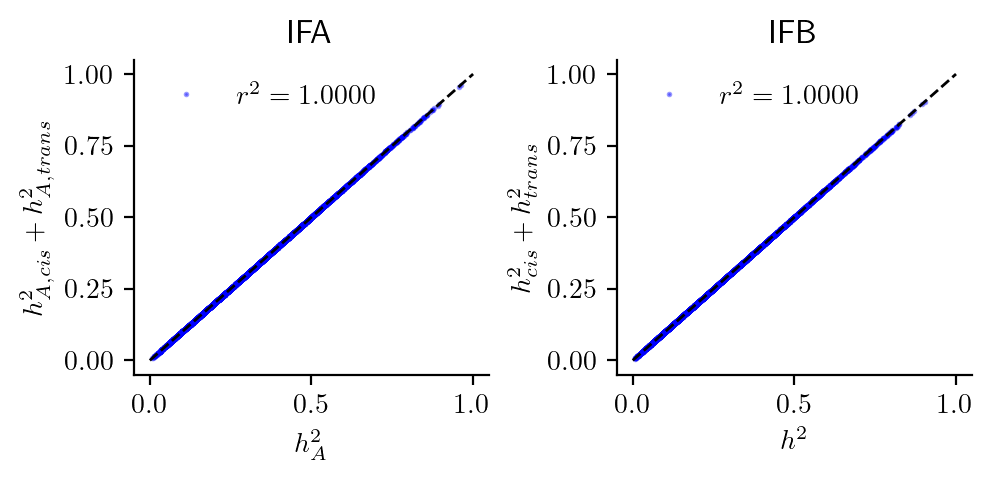

In [3]:
# compare h2 with sum of cis and trans, just to be sure!
fig, axs = plt.subplots(1, 2, dpi=200, figsize=(5, 2.5))

# IFA
ax = axs[0]
ax.plot(
    h2a['IFAh2'],
    h2a['IFAh2cis'] + h2a['IFAh2trans'],
    'b.',
    alpha = 0.4,
    ms = 2,
    label = r'$r^2 = {:.4f}$'.format(
        ss.pearsonr(h2a['IFAh2'], h2a['IFAh2cis'] + h2a['IFAh2trans'])[0] ** 2
    ),
)

ax.plot([0,1],[0,1],'k--',linewidth=1)
ax.set_xlabel(r'$h^2_{A}$'); 
ax.set_ylabel(r'$h^2_{A,cis} + h^2_{A,trans} $'); 
ax.legend(frameon=0);
ax.set_title('IFA');

# IFB
ax = axs[1]
ax.plot(
    h2b['IFBh2'],
    h2b['IFBh2cis'] + h2b['IFBh2trans'],
    'b.',
    alpha = 0.4,
    ms = 2,
    label = r'$r^2 = {:.4f}$'.format(
        ss.pearsonr(h2b['IFBh2'], h2b['IFBh2cis'] + h2b['IFBh2trans'])[0] ** 2
    ),
)

ax.plot([0,1],[0,1],'k--',linewidth=1)
ax.set_xlabel(r'$h^2$'); 
ax.set_ylabel(r'$h^2_{cis} + h^2_{trans} $'); 
ax.legend(frameon=0);
ax.set_title('IFB');

sns.despine();
fig.tight_layout();

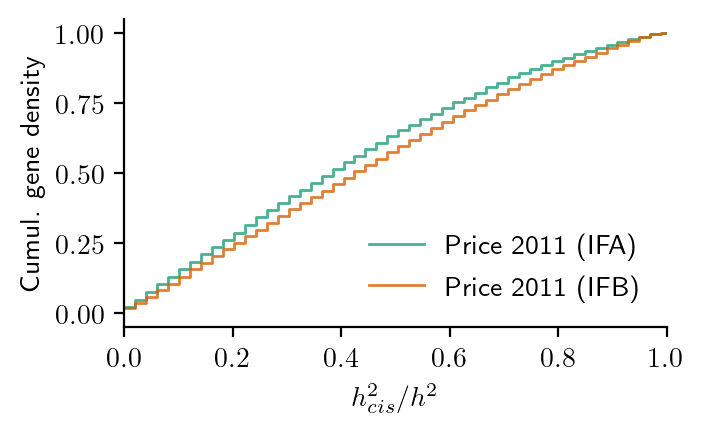

In [4]:
# cumulative heritablity
fig, ax = plt.subplots(1, 1, dpi=200, figsize=(3.5, 2));

x_bins = np.linspace(0, 1.01, 51)

for fracs, label in zip([price_h2_cis_a, price_h2_cis_b], 'AB'):
    
    x = np.cumsum(np.histogram(fracs, bins = x_bins)[0])

    ax.step(
        x_bins, 
        np.hstack([x, 0]) / fracs.shape[0], 
        where = 'post', 
        linewidth = 1, 
        alpha = 0.8,
        label = 'Price 2011 (IF{})'.format(label),
    )

ax.legend(frameon=0);
ax.set_xlim(0, 1); 
ax.set_ylim(-0.05, 1.05);
ax.set_xlabel(r'$h^2_{cis}/h^2$');
ax.set_ylabel('Cumul. gene density');
sns.despine();

# Synthetic Networks

Uses data from directed scale-free DAGs.

In [5]:
grn_file = 'figdata/dsfg.graphs.parquet'

grns = pd.read_parquet(grn_file)

# define some convenience variables
n_sims = grns.shape[0]

grns['Median '+r'$V_{cis}/V_{G}$'] = grns['Median '+r'$V_{cis}/V_{tot}$']
grns[r'$V_{cis}/V_{G}$'] = grns[r'$V_{cis}/V_{tot}$']
grns['log_d'] = np.log(grns['d'])
grns[r'$r \gamma^2$'] = grns['r'] * (grns['gamma'] ** 2)

display(grns.head())

,model,n,r,k,d,gamma,p_up,hier,w,m,$V_{cis}/V_{tot}$,$max(B_{trans}^2/V_{cis})$,triangles,diamonds,Median $V_{cis}/V_{tot}$,Median $V_{cis}/V_{G}$,$V_{cis}/V_{G}$,log_d,$r \gamma^2$
0,dsfg,5000,5.425033,55,2.032283,0.308603,0.423356,False,33.545004,0.383174,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[8.881784197001244e-16, 2.436135136536793e-29,...",5338,16739,0.582176,0.582176,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.709160,0.516657
1,dsfg,5000,4.123642,37,19.513432,0.377517,0.901563,False,145.183981,0.801307,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.778...","[4.440892098500624e-16, 1.630107104929357e-30,...",3440,7340,0.358481,0.358481,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.778...",2.971103,0.587697
2,dsfg,5000,6.016103,79,11.148670,0.314075,0.177089,False,408.232486,0.839583,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[2.1573443450584817e-31, 2.0135717939190173e-3...",15771,37077,0.596487,0.596487,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",2.411320,0.593449
3,dsfg,5000,8.279217,55,4.411394,0.302969,0.070393,False,17.297478,0.242610,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.915...","[2.6645352591003686e-15, 4.884981308350665e-15...",10263,54124,0.433683,0.433683,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.915...",1.484191,0.759949
4,dsfg,5000,5.967968,65,1.131192,0.447152,0.570080,False,59.219359,0.480601,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[1.2604358664862946e-30, 1.1546319456101495e-1...",8061,22041,0.290483,0.290483,"[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...",0.123272,1.193265


## Match on $h^2_{cis}$ distribution

In [6]:
grns[['price_a_ks_stat','price_a_ks_p']] = [ss.ks_2samp(v, price_h2_cis_a, method='asymp')[:2] for v in grns['$V_{cis}/V_{G}$']]
grns[['price_b_ks_stat','price_b_ks_p']] = [ss.ks_2samp(v, price_h2_cis_b, method='asymp')[:2] for v in grns['$V_{cis}/V_{G}$']]

grns[['price_a_ks_p','price_b_ks_p']].clip(lower=1e-300).apply(lambda x: -np.log10(x)).describe()

,price_a_ks_p,price_b_ks_p
count,10000.000000,10000.000000
mean,269.049098,265.140041
std,63.996575,66.172973
min,11.194622,14.122085
25%,298.313382,264.789860
50%,300.000000,300.000000
75%,300.000000,300.000000
max,300.000000,300.000000


In [7]:
grns[['price_a_ks_stat','price_b_ks_stat']].describe()

,price_a_ks_stat,price_b_ks_stat
count,10000.000000,10000.000000
mean,0.486484,0.476075
std,0.196161,0.189099
min,0.064152,0.075399
25%,0.323364,0.319812
50%,0.475420,0.462117
75%,0.637327,0.615163
max,0.982995,0.984567


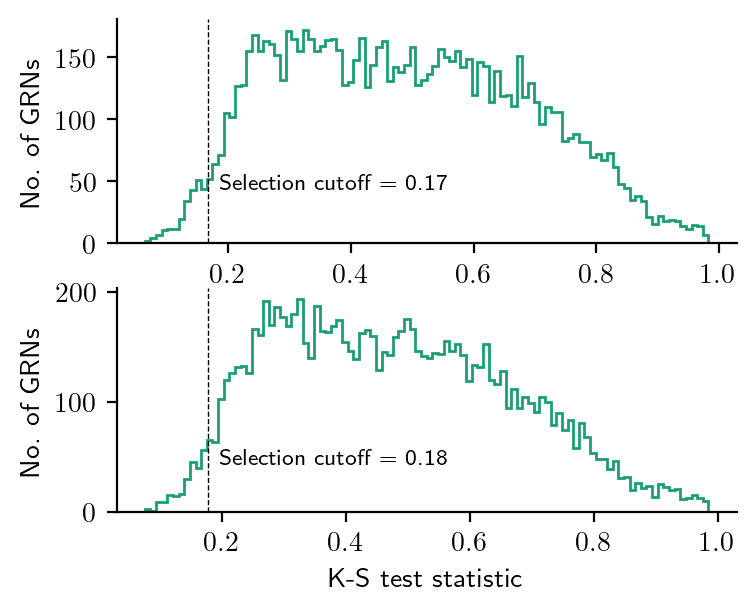

In [8]:
fig, axs = plt.subplots(2, 1, figsize=(4, 3.2), dpi=200);

ax = axs[0]

ax.hist(grns['price_a_ks_stat'], bins=100, histtype='step'); # plt.semilogy();

q_ks_a = grns['price_a_ks_stat'].quantile(250 / n_sims)
ax.axvline(q_ks_a, linewidth=0.5, color='k', linestyle='--');

ax.set_xlabel('K-S test statistic');
ax.set_ylabel('No. of GRNs');
ax.text(q_ks_a + 0.02, 40, 'Selection cutoff = {:.2f}'.format(q_ks_a), fontsize=8, ha='left', va='bottom');


ax = axs[1]

ax.hist(grns['price_b_ks_stat'], bins=100, histtype='step'); # plt.semilogy();

q_ks_b = grns['price_b_ks_stat'].quantile(250 / n_sims)
ax.axvline(q_ks_b, linewidth=0.5, color='k', linestyle='--');

ax.set_xlabel('K-S test statistic');
ax.set_ylabel('No. of GRNs');
ax.text(q_ks_b + 0.02, 40, 'Selection cutoff = {:.2f}'.format(q_ks_b), fontsize=8, ha='left', va='bottom');

sns.despine();

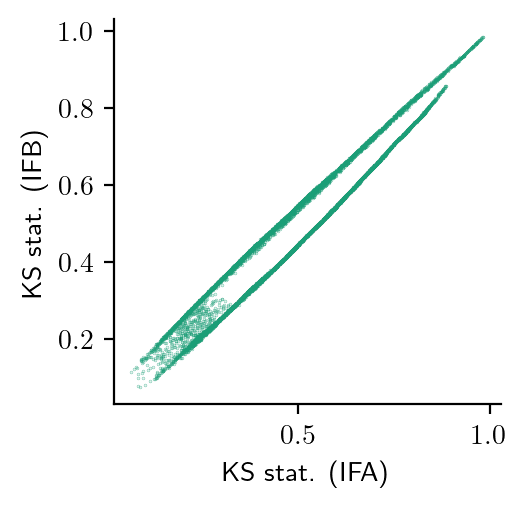

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(2.5, 2.5), dpi=200)

grns.plot.scatter(
    x = 'price_a_ks_stat',
    y = 'price_b_ks_stat',
    ax = ax,
    s = 0.03,
    alpha = 0.7
);

ax.set_xlabel('KS stat. (IFA)');
ax.set_ylabel('KS stat. (IFB)');
sns.despine();

In [10]:
grns['selected_a'] = (grns['price_a_ks_stat'] < q_ks_a)
grns['selected_b'] = (grns['price_b_ks_stat'] < q_ks_b)

print(grns['selected_a'].sum(), grns['selected_b'].sum(), (grns['selected_a'] & grns['selected_b']).sum())

250 250 141


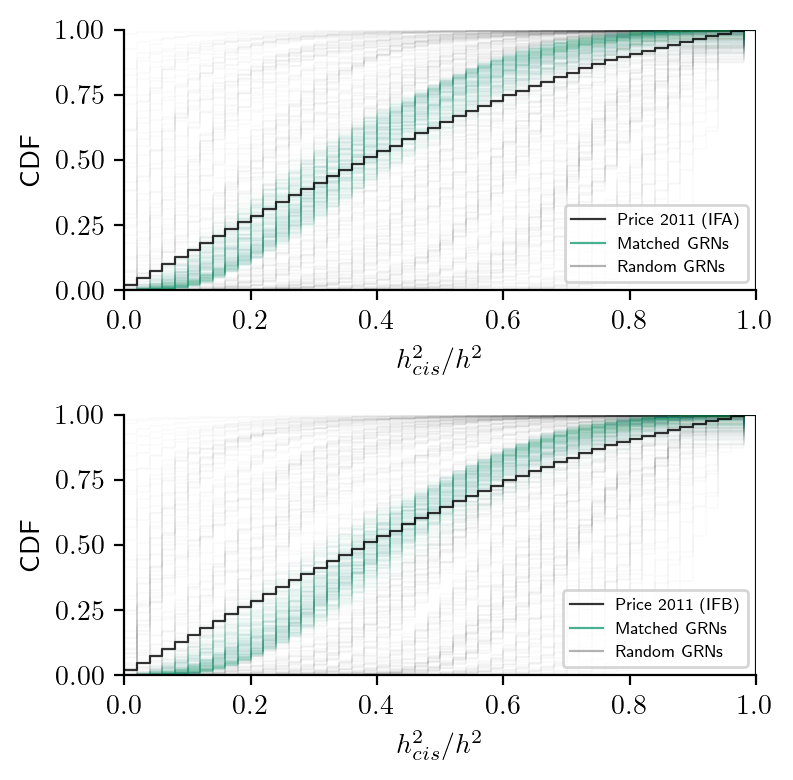

In [11]:
fig, axs = plt.subplots(2, 1, figsize=(4, 4), dpi=200)


x_bins = np.linspace(0, 1, 51)

for i,(ab,fracs) in enumerate([('A',price_h2_cis_a), ('B',price_h2_cis_b)]):
    ax = axs[i]
    
    # random grns
    for _,row in grns.query('~selected_{}'.format(ab.lower())).sample(250).iterrows():
        # compute values
        x = np.cumsum(np.histogram(row['$V_{cis}/V_{G}$'], bins = x_bins)[0])

        # plot
        ax.step(
            x_bins, 
            np.hstack([x, 0])/row.n, 
            where='post', 
            linewidth=0.1, 
            alpha=0.1, 
            color='k',
            label=None
        )


    # good grns
    for _,row in grns.query('selected_{}'.format(ab.lower())).sample(250).iterrows():
        # compute values
        x = np.cumsum(np.histogram(row['$V_{cis}/V_{G}$'], bins = x_bins)[0])

        # plot
        ax.step(
            x_bins, 
            np.hstack([x, 0])/row.n, 
            where='post', 
            linewidth=0.1, 
            alpha=0.1, 
            color=plt.get_cmap('Dark2')(0),
            label=None
        )

    # price (A)
    x = np.cumsum(np.histogram(price_h2_cis_a, bins = x_bins)[0])


    ax.step(
        x_bins, 
        np.hstack([x, 0]) / price_h2_cis_a.shape[0], 
        where='post', 
        color='k', 
        linewidth=0.8, 
        alpha=0.8,
        label='Price 2011 (IF{})'.format(ab)
    )



    # fake legend
    ax.plot(
        [], [],
        color=plt.get_cmap('Dark2')(0),
        linestyle='-',
        linewidth=0.8,
        marker='',
        alpha=0.8,
        label='Matched GRNs'
    )

    ax.plot(
        [], [],
        color='k',
        marker='',
        linestyle='-',
        linewidth=0.8,
        alpha=0.3,
        label='Random GRNs'
    )

    ax.set_xlim(0,1); 
    ax.set_xlabel(r'$h^2_{cis} / h^2$');

    ax.set_ylim(0,1);
    ax.set_ylabel('CDF');
    ax.legend(frameon=1, loc='lower right', fontsize=6);


fig.tight_layout();
sns.despine();
#plt.savefig('png/supplement/Fig_Sx_Price2011a.png')

In [12]:
model_tri = sm.ols('np.log(triangles) ~ 1 + r + m + log_d', data = grns).fit()
model_dia = sm.ols('np.log(diamonds) ~ 1 + r + m + log_d', data = grns).fit()
grns['tri_resid'] = model_tri.resid
grns['dia_resid'] = model_dia.resid
print(model_tri.summary())
print(model_dia.summary())

                            OLS Regression Results                            
Dep. Variable:      np.log(triangles)   R-squared:                       0.873
Model:                            OLS   Adj. R-squared:                  0.873
Method:                 Least Squares   F-statistic:                 2.291e+04
Date:                Sat, 14 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:34:46   Log-Likelihood:                -7632.4
No. Observations:               10000   AIC:                         1.527e+04
Df Residuals:                    9996   BIC:                         1.530e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.1313      0.019    263.360      0.0

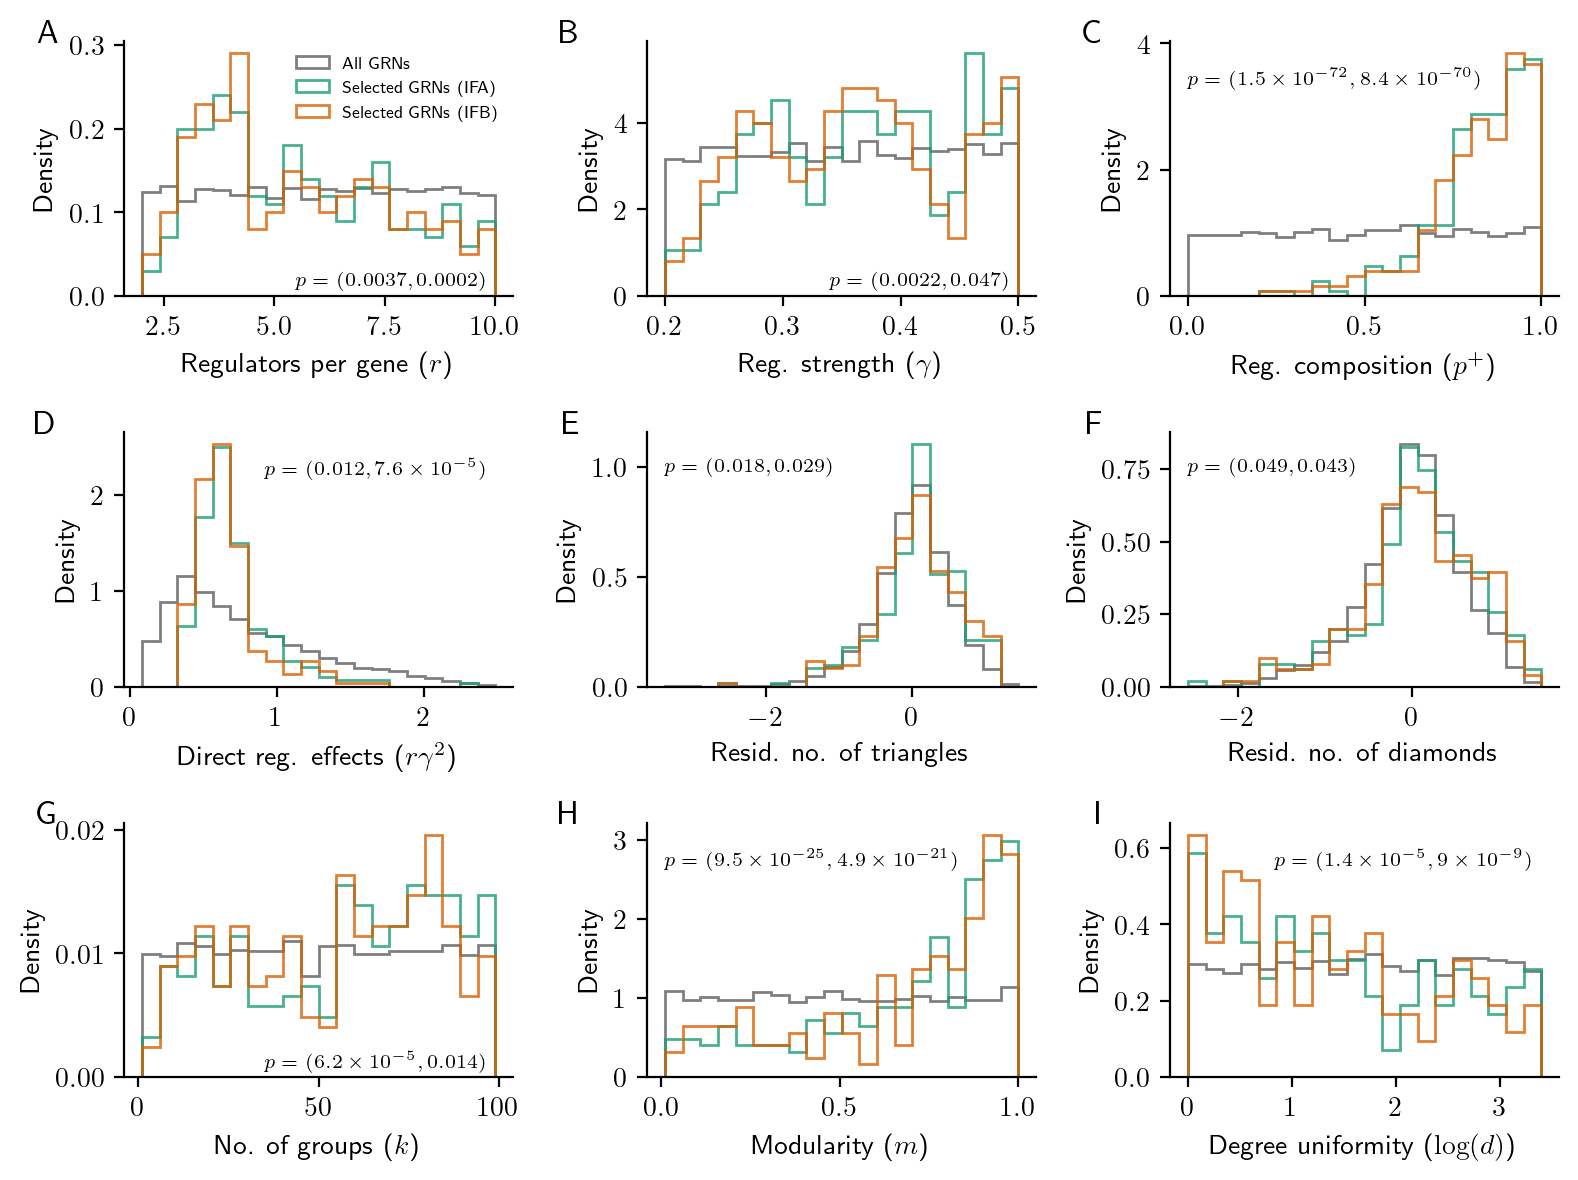

In [13]:
fig, axs = plt.subplots(3, 3, figsize=(8, 6), dpi=200);

for ix, (par, label),      letter in zip([(ix,iy) for ix in range(axs.shape[0]) for iy in range(axs.shape[1])],
                                         {
                                             'r': 'Regulators per gene ({})'.format(r'$r$'),
                                             'gamma': 'Reg. strength ({})'.format(r'$\gamma$'),
                                             'p_up': 'Reg. composition ({})'.format(r'$p^+$'),
                                             r'$r \gamma^2$': 'Direct reg. effects ({})'.format(r'$r \gamma^2$'),
                                             'tri_resid': 'Resid. no. of triangles',
                                             'dia_resid': 'Resid. no. of diamonds',
                                             'k': 'No. of groups ({})'.format(r'$k$'),
                                             'm': 'Modularity ({})'.format(r'$m$'),
                                             'log_d': 'Degree uniformity ({})'.format(r'$\log(d)$')
                                         }.items(),
                                       'ABCDEFGHI'
                                      ):
    ax = axs[ix]
    # plot background
    _, bins, _ = ax.hist(
            grns[par], 
            histtype = 'step', 
            density = True, 
            alpha = 0.5, 
            color = 'k', 
            bins=20,
            label = 'All GRNs'
    );
    
    # plot selected
    _ = ax.hist(
            grns.query('selected_a')[par], 
            bins = bins, 
            histtype = 'step', 
            density = True, 
            alpha = 0.8,
            label = 'Selected GRNs (IFA)'
    );
    
    _ = ax.hist(
            grns.query('selected_b')[par], 
            bins = bins, 
            histtype = 'step', 
            density = True, 
            alpha = 0.8,
            label = 'Selected GRNs (IFB)'
    );
        
    ax.set_xlabel(label);
    ax.set_ylabel('Density');
    
    if par in ['p_up', r'$r \gamma^2$', 'tri_resid', 'dia_resid', 'm', 'log_d']:
        va = 'top'
        yy = 0.9
    else:
        va = 'bottom'
        yy = 0.02
    
    if par in ['p_up','tri_resid','dia_resid','m']:
        ha = 'left'
        xx = 0.04
    else:
        ha = 'right'
        xx = 0.93
    
    ax.text(
        xx, 
        yy,
        #r'$t=({0:.1f},{2:.1f}) \\ p=(\num{{{1:.2g}}}, \num{{{3:.2g}}})$'.format(
        r'$p=(\num{{{1:.2g}}}, \num{{{3:.2g}}})$'.format(
            *ss.ttest_ind(
                grns.loc[grns.selected_a, par], 
                grns.loc[~grns.selected_a, par]
            ),
            *ss.ttest_ind(
                grns.loc[grns.selected_b, par], 
                grns.loc[~grns.selected_b, par]
            ),
        ),
        fontsize=7,
        transform=ax.transAxes,
        ha = ha, 
        va = va 
    );
    
    ax.text(-0.17, 0.97, letter, fontsize=12, ha='right', va='bottom', transform=ax.transAxes)
    
    if letter == 'A':
        ax.legend(frameon=0, fontsize=6, loc = 'upper right');
        
fig.tight_layout();
sns.despine();
#plt.savefig('png/supplement/Fig_Sx_Price2011b.png')